<a href="https://colab.research.google.com/github/17Juan08/Spotify_Streaming_Audit/blob/main/Group4_Spotify_Streaming_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Streaming Audit

## 1. Objetivo del proyecto

## 2. Metodología Agile del equipo

## 3. Roles y responsabilidades

## 4. Tratamiento de datos

## 5. Análisis exploratorio EDA

## 6. Análisis SQL con DuckDB

## 7. Análisis estadístico

## 8. Modelado predictivo

## 9. Clustering de vibes musicales

## 10. Dashboard y visualizaciones

## 11. Recomendaciones de negocio

## 12. Limitaciones

## 13. Próximos pasos

### Team Members group 4
- Jacqueline Verónica Villagómez
- Juan David Alvarado Camacho
- José Enrique Piñangp Bustamante
- Jefferson Torres

## Contexto del negocio

Spotify cuenta actualmente con un catálogo de más de 2000 canciones, pero carece de una estrategia basada en datos para determinar qué canciones deben incluirse en las listas de reproducción premium.

Sin un marco de selección claro, la empresa corre el riesgo de promocionar canciones con bajo rendimiento, lo que reduce la interacción de los usuarios y la efectividad de las listas de reproducción.

## 1. Objetivo del proyecto

Analizar el catálogo de canciones de Spotify para identificar patrones relacionados con la popularidad, segmentar el catálogo según características musicales y proponer criterios de selección para playlists premium.

El análisis ***PODRÍA*** responder preguntas como:

- ¿Qué géneros o segmentos musicales presentan mayor popularidad?
- ¿Qué décadas concentran canciones con mejor desempeño?
- ¿Qué atributos acústicos se relacionan con canciones más populares?
- ¿Qué grupos de canciones podrían priorizarse para playlists premium?


El resultado final será una recomendación de negocio respaldada por datos, acompañada de análisis exploratorio, consultas SQL, visualizaciones interactivas, modelo predictivo y clustering de canciones.

## 2. Metodología Agile del equipo

El proyecto se desarrollará como un sprint corto de 7 días, siguiendo una dinámica Agile adaptada al calendario del reto.

La prioridad será avanzar de forma iterativa: primero entender el problema de negocio, después explorar los datos, luego construir análisis reproducibles y finalmente traducir los hallazgos en una recomendación ejecutiva.

### Dinámica de trabajo

| Actividad | Frecuencia | Objetivo |
|---|---:|---|
| Revisión interna del equipo | Diario | Revisar avances, bloqueos y pendientes |
| Check-in con Product Owner | Días hábiles del sprint | Validar que el análisis siga alineado al negocio |
| Control de avances en GitHub | Diario | Mantener trazabilidad del trabajo |
| Revisión cruzada | Antes del cierre técnico | Confirmar que los entregables sean claros y reproducibles |
| Ensayo del pitch | Martes 2 de junio | Preparar una presentación ejecutiva enfocada en negocio |

### Criterio de avance

Cada avance deberá cumplir con tres condiciones:

**1. Responder una pregunta de negocio.**

**2. Estar respaldado por datos.**

**3. Poder ser explicado a una audiencia no técnica.**

## 3. Roles y responsabilidades

El equipo está formado por dos perfiles de Data Analyst y dos perfiles de Data Scientist. La distribución de tareas busca ser proporcional, pero no idéntica. Cada integrante asume entregables alineados con su perfil técnico, manteniendo responsabilidades compartidas en documentación, revisión del repositorio y construcción del pitch ejecutivo.

| Integrante | Perfil | Responsabilidades principales |
|---|---|---|
| Juan David Alvarado Camacho | Data Scientist / Líder | Coordinación del equipo, modelo predictivo, comparación de algoritmos, documentación de métricas de regresión y apoyo al cierre técnico |
| Jefferson Torres | Data Scientist | Clustering de canciones, normalización de variables, cálculo de Silhouette Score, visualización de clusters, nombres interpretables y apoyo en `requirements.txt` |
| José Enrique Piñango Bustamante | Data Analyst | Consultas SQL con DuckDB, análisis estadístico, segmentación por década y cuartiles de Popularity, interpretación de negocio y redacción de hallazgos para el README |
| Jacqueline Veronica Villagomez Rodriguez | Data Analyst | Análisis exploratorio visual, diseño del dashboard, visualizaciones interactivas, storytelling visual y documentación de visualizaciones para el README |

### Responsabilidades compartidas

- Mantener el notebook limpio y reproducible.
- Documentar decisiones importantes.
- Revisar que cada visualización responda una pregunta de negocio.
- Evitar gráficos decorativos sin valor analítico.
- Confirmar que los hallazgos estén respaldados por datos.
- Participar en la construcción del pitch ejecutivo.
- Revisar que el repositorio final sea claro, profesional y reproducible.

### Criterio de equilibrio del trabajo

La carga se distribuye de forma aproximada en cuatro partes:

| Integrante | Carga estimada | Tipo de contribución |
|---|---:|---|

| Juan | 25% | Liderazgo, modelo predictivo e integración técnica |
| Jefferson | 25% | Clustering, métricas de agrupamiento y soporte técnico |
| José Enrique | 25% | SQL, análisis estadístico e interpretación de negocio |
| Jacqueline | 25% | EDA visual, dashboard y narrativa visual |

Aunque Juan **ASUMIECE **el liderazgo, las tareas de documentación, revisión del repositorio y preparación del pitch serán compartidas para evitar una sobrecarga individual.

# TRATAMIENTO DE DATOS


# 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import seaborn as sns
import plotly.express as px
import duckdb
import joblib
import re

2.1 Funciones

In [ ]:
def clean_column_name(name):
    # Convertir a minúsculas, reemplazar espacios por _, eliminar caracteres no alfanuméricos
    name = name.lower().strip()
    name = re.sub(r'[\s\-\.]+', '_', name)
    name = re.sub(r'[^a-z0-9_]', '', name)
    return name

3.Carga de dataset

In [ ]:
# The file ID extracted from your link
file_id = '16IRW1v7iFndjO_DzVLmVZdmt1J_-xe57'
file_id_2 = '1nODybfk9QTXcYQDbRX3TWDu0x_0q9mlx'
# Converting the sharing link to a direct download link
url = f'https://drive.google.com/uc?id={file_id}&export=download'
url_2 = f'https://drive.google.com/uc?id={file_id_2}&export=download'


df = pd.read_csv(url)
df_2 = pd.read_csv(url_2)
df.head()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   object
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [ ]:
df_2.head()


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


### 4.1. Limpieza Inicial y Normalización de Datos
En esta sección se realiza la limpieza del dataset `df` siguiendo estándares de la industria para asegurar la integridad del análisis.

In [ ]:
df.columns = [clean_column_name(col) for col in df.columns]
print(f"Nuevas columnas: {df.columns.tolist()}\n")

# 2. Resetear el Index
if 'index' in df.columns:
    df = df.drop(columns=['index'])
df = df.reset_index(drop=True)

# 3. Corrección de Tipos de Datos
# 'length_duration' viene como objeto (string), intentamos convertirlo a int
# Primero eliminamos comas si las hay (ej. '1,234')
if df['length_duration'].dtype == 'object':
    df['length_duration'] = df['length_duration'].str.replace(',', '').astype(int)

# Convertir variables categóricas para optimizar memoria
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['artist'] = df['artist'].astype('string')
df['top_genre'] = df['top_genre'].astype('category')

# 4. Revisión y Eliminación de Duplicados
num_duplicados = df.duplicated().sum()
print(f"\n[INFO] Registros duplicados detectados: {num_duplicados}")
if num_duplicados > 0:
    print("Mostrando filas duplicadas:")
    print(df[df.duplicated()])
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print("Duplicados eliminados exitosamente.")

# Verificación final
print("\nResumen del DataFrame actualizado:")
df.info()
display(df.head())

Nuevas columnas: ['index', 'title', 'artist', 'top_genre', 'year', 'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness', 'popularity']


[INFO] Registros duplicados detectados: 0

Resumen del DataFrame actualizado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   title                 1994 non-null   object  
 1   artist                1994 non-null   string  
 2   top_genre             1994 non-null   category
 3   year                  1994 non-null   int64   
 4   beats_per_minute_bpm  1994 non-null   int64   
 5   energy                1994 non-null   int64   
 6   danceability          1994 non-null   int64   
 7   loudness_db           1994 non-null   int64   
 8   liveness              1994 non-null   int64   
 9   valence          

,title,artist,top_genre,year,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


#5.**EDA**

5.1 Análisis Univariado (Distribuciones)

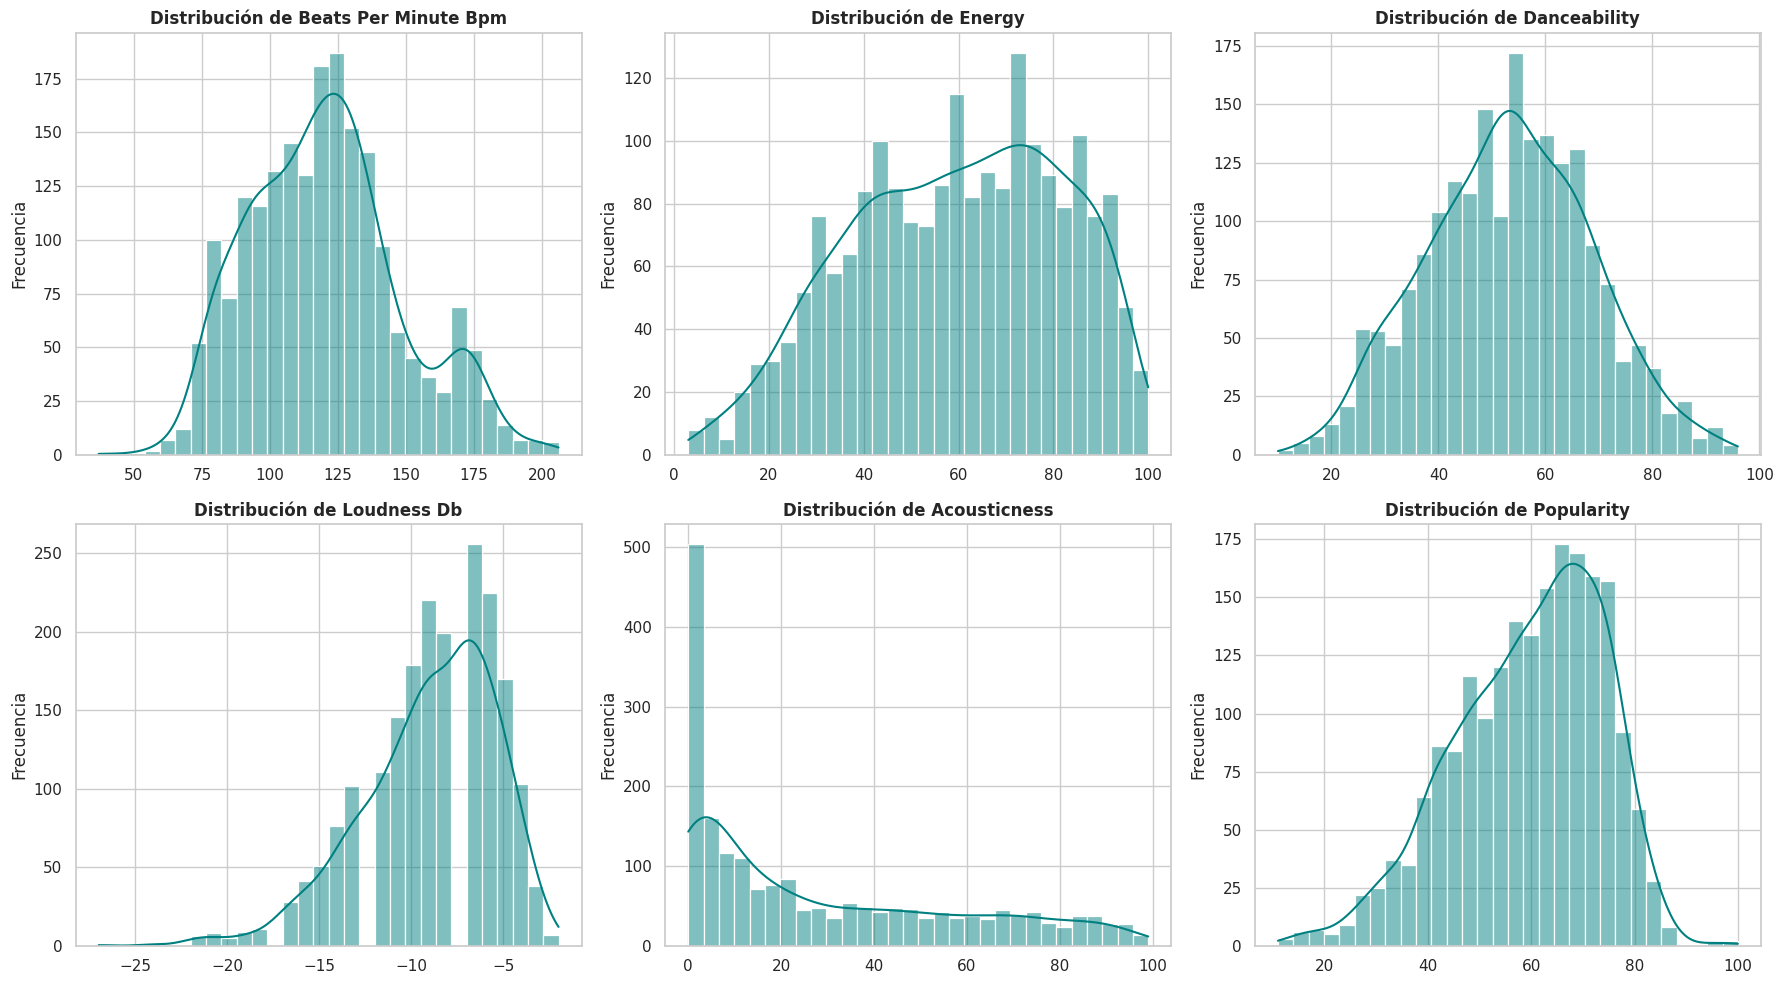

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. SELECCIÓN DE VARIABLES CLAVE
# Elegimos las métricas musicales más importantes para ver su comportamiento
variables_audio = ['beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 'acousticness', 'popularity']

# Crear una cuadrícula de gráficos (2 filas x 3 columnas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Aplanar la matriz para iterar fácilmente

# 2. BUCLE AUTOMÁTICO DE DISTRIBUCIONES
for i, col in enumerate(variables_audio):
    if col in df.columns:
        # Dibujar el histograma con la curva de densidad (KDE)
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'Distribución de {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frecuencia')

# Ajustar diseño para que no se traslapen
plt.tight_layout()
plt.show()

1. Beats Per Minute (BPM)
 El grueso de los éxitos se mueve en el "ritmo cardíaco" estándar del Pop y el Rock (110-130 BPM), ideal para radio y discotecas. Sin embargo, ese segundo pico a 170 BPM revela la fuerte presencia de géneros más acelerados (como el Rock clásico, Punk o Drum & Bass) que también lograron ser masivos.

2. Energy & Danceability (Energía y Bailabilidad)
 Para que una canción entre en este Top 2000, la energía es casi un requisito base (hay poquísimas canciones con energía menor a 20). En cambio, la bailabilidad es más flexible: el público consume canciones con un nivel de baile promedio, sin necesidad de que todo sea música estrictamente coreográfica.

3. Loudness Db (Volumen / Sonoridad)
 Esto es un reflejo matemático de la famosa "Loudness War" (Guerra del Volumen) de la industria musical. Las canciones comerciales se masterizan para sonar lo más fuerte posible para captar la atención del oyente. Los valores por debajo de -15 dB son anomalías o baladas extremadamente acústicas.

4. Acousticness (Acústica)
 El Top 2000 está dominado por música altamente producida, amplificada y electrónica (guitarras eléctricas, sintetizadores, cajas de ritmos). Las canciones puramente acústicas o desconectadas (valores cercanos a 100) son auténticas rarezas dentro del gusto popular masivo.

5. Popularity (Popularidad)
 Al ser un dataset que recopila éxitos históricos, la base de popularidad ya es alta de por sí. El hecho de que caiga tan rápido después de los 80 puntos demuestra lo difícil que es mantenerse en el "Olimpo" de las canciones ultra-populares a nivel mundial; solo un selecto grupo logra cruzar esa barrera.

5.3 Analisís de correlaciones



--- Resumen Estadístico de las Métricas de Audio ---
                       count         mean        std     min      25%     50%  \
year                  1994.0  1992.992979  16.116048  1956.0  1979.00  1993.0   
beats_per_minute_bpm  1994.0   120.215647  28.028096    37.0    99.00   119.0   
energy                1994.0    59.679539  22.154322     3.0    42.00    61.0   
danceability          1994.0    53.238215  15.351507    10.0    43.00    53.0   
loudness_db           1994.0    -9.008526   3.647876   -27.0   -11.00    -8.0   
liveness              1994.0    19.012036  16.727378     2.0     9.00    12.0   
valence               1994.0    49.408726  24.858212     3.0    29.00    47.0   
length_duration       1994.0   262.443330  93.604387    93.0   212.00   245.0   
acousticness          1994.0    28.858074  29.011986     0.0     3.00    18.0   
speechiness           1994.0     4.994985   4.401566     2.0     3.00     4.0   
popularity            1994.0    59.526580  14.351600   

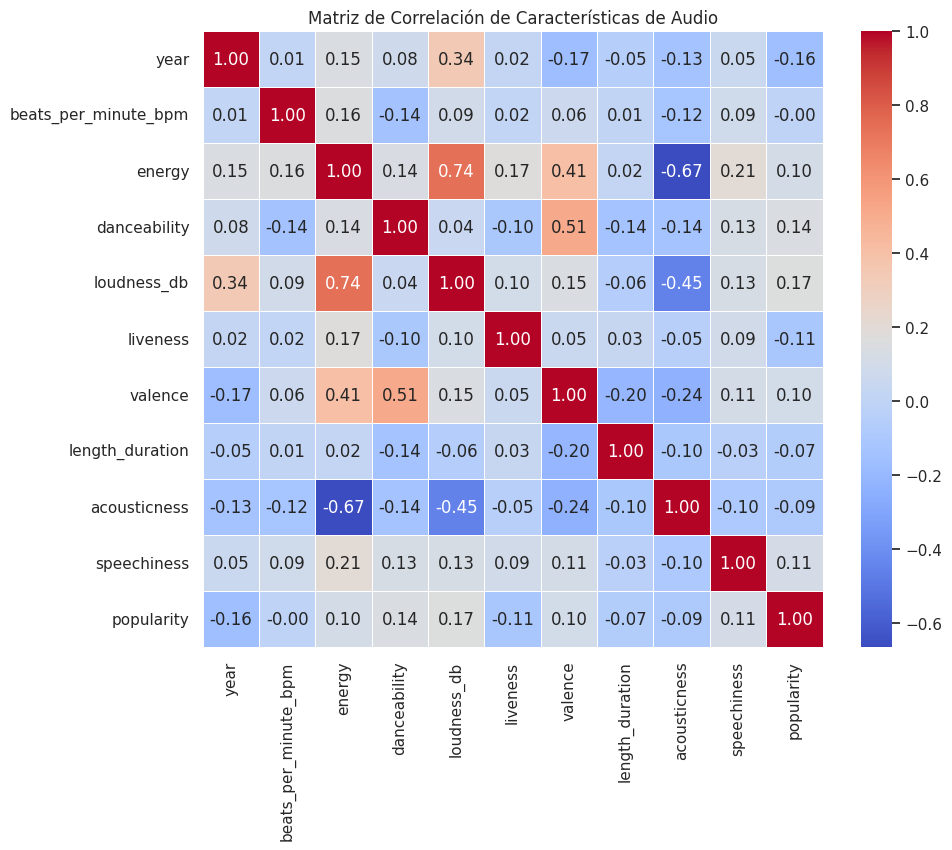

In [ ]:
print("\n--- Resumen Estadístico de las Métricas de Audio ---")
print(df.describe().T)

# Gráfico 3: Matriz de Correlación (Métricas de audio)
plt.figure(figsize=(10, 8))
# Definir las columnas numéricas para la matriz de correlación
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[columnas_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Características de Audio')
plt.show()

Al mirar la matriz, se destaca tres hallazgos críticos para la toma de decisiones:

1.	La fila de la variable popularidad  tiene coeficientes muy bajos con todas las demás a excepción de loudness_db con solo 0.17. Es decir que las canciones un poco más fuertes tienden a ser ligeramente más populares en el catálogo.   Pero no es un atributo para que se añada la lista Premium por sí sola.  


2.	El Eje de la Intensidad Musical: La correlación positiva más fuerte de todo el catálogo es entre energy y loudness_db (0.74), y ambas tienen una fuerte correlación negativa con acousticness (-0.67 y -0.45). Es decir, que el catálogo se divide de forma natural por su "fuerza". Esto segmenta la música en dos grandes bloques: producciones enérgicas/fuertes frente a producciones acústicas/orgánicas.

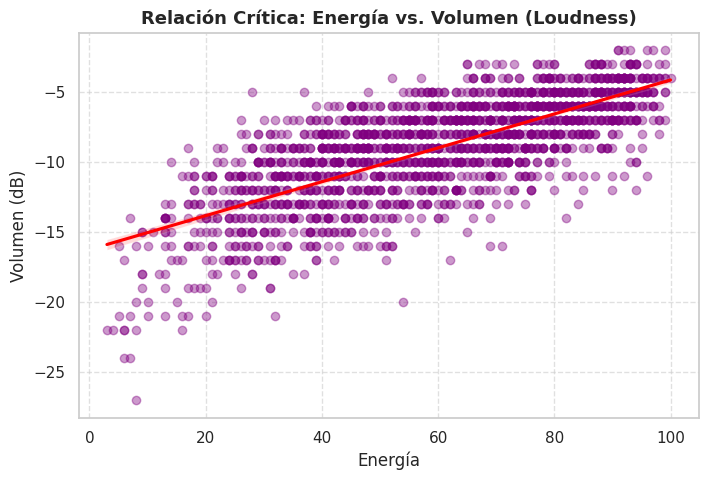

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='energy', y='loudness_db',
            scatter_kws={'alpha':0.4, 'color': 'purple'}, line_kws={'color': 'red'})
plt.title('Relación Crítica: Energía vs. Volumen (Loudness)', fontsize=13, fontweight='bold')
plt.xlabel('Energía')
plt.ylabel('Volumen (dB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Conclusión

•  Existe una fuerte correlación positiva de 0.74. El gráfico muestra que al superar los 40 puntos de energía, el volumen se estabiliza de forma competitiva entre -10 dB y -4 dB. Por debajo de 20 puntos de energía, el volumen colapsa y se dispersa de manera inconsistente hasta los -25 dB.

•  Para garantizar una experiencia Premium uniforme y evitar saltos abruptos de volumen en playlists dinámicas (Workouts, Party), debemos automatizar un filtro técnico estricto: Energía 50 y Volumen entre -7 dB y -4 dB


3.	El Factor Ánimo y Ritmo: Hay una correlación moderada-alta entre valence (ánimo positivo) y danceability (0.51). Es decir, las canciones alegres incitan al movimiento, lo que abre un segmento claro para playlists de "Alta Energía / Fiesta".

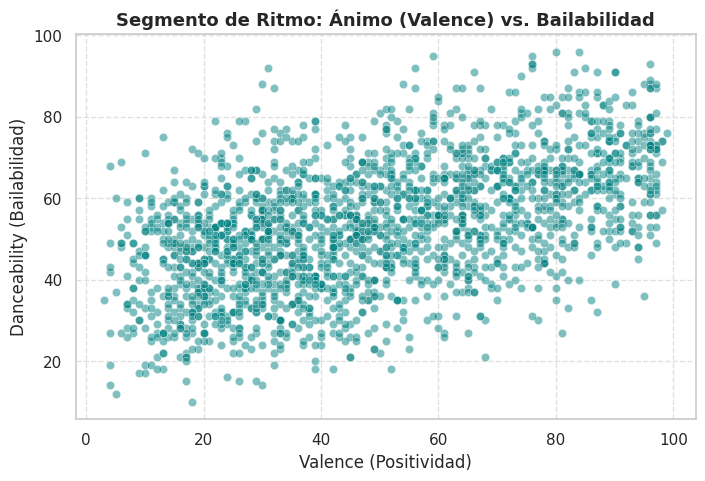

In [ ]:
plt.figure(figsize=(8, 5))
# Usamos un scatter plot con transparencias o un jointplot para ver densidad
sns.scatterplot(data=df, x='valence', y='danceability', alpha=0.5, color='teal')
plt.title('Segmento de Ritmo: Ánimo (Valence) vs. Bailabilidad', fontsize=13, fontweight='bold')
plt.xlabel('Valence (Positividad)')
plt.ylabel('Danceability (Bailabilidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Conclusión

•  Tienen una correlación moderada de 0.51. La masa crítica de canciones se concentra fuertemente en el cuadrante superior derecho: Valence > 50 y Danceability > 55. Las excepciones (música triste/bailable o alegre/estática) son muy aisladas.

•  Para automatizar listas de reproducción Premium enfocadas en elevar el ánimo (Mood Booster), la métrica exige un filtro combinado: establecer un piso mínimo de 50 puntos en ambas variables. Esto garantiza canciones que comercialmente transmitan optimismo e inciten al movimiento, asegurando el engagement.


## CONCLUSIÓN GENERAL

El éxito de una canción dentro de la plataforma no se explica mediante variables aisladas, sino por la combinación multivariada de las mismas. Por lo que es necesario:

1.	El uso de Clustering (K-Means) para agrupar el catálogo en segmentos basados en la combinación de potencia (Energía/Volumen) y ritmo (Bailabilidad/Valence).

2.	El uso de Modelos de Regresión para encontrar interacciones complejas no lineales que logren predecir con mayor precisión la métrica de popularity.


6. TRATAMIENTO DE OUTLIERS

In [ ]:
# 1. Copia de trabajo
df_clean = df.copy()

In [ ]:
# 2. Winsorización (IQR Capping) para variables continuas
cols_to_cap = ['length_duration', 'loudness_db']

for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# 3. Detección Multivariable (Isolation Forest)
acoustic_features = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness'
]

iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['outlier_flag'] = iso_forest.fit_predict(df_clean[acoustic_features])

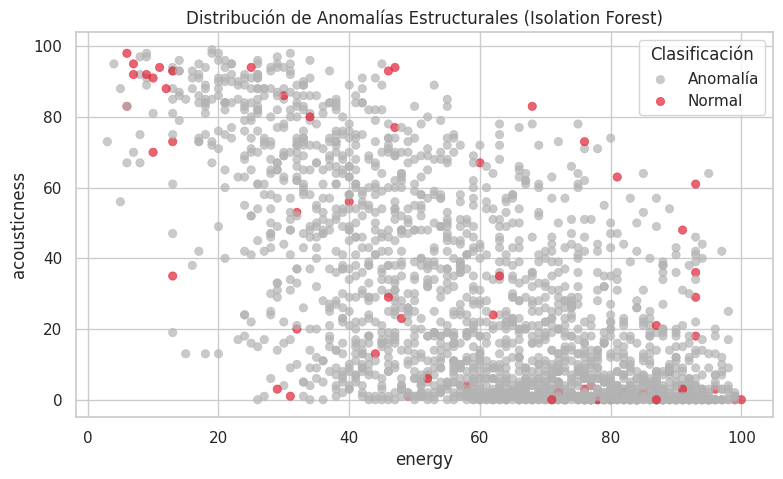

In [ ]:
# 4. Visualización del espacio latente (Energía vs Acústica)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_clean,
    x='energy',
    y='acousticness',
    hue='outlier_flag',
    palette={1: '#b3b3b3', -1: '#E22134'},
    alpha=0.7,
    edgecolor=None
)
plt.title('Distribución de Anomalías Estructurales (Isolation Forest)')
plt.legend(title='Clasificación', labels=['Anomalía', 'Normal'])
plt.show()

In [ ]:
# 5. Consolidación del dataset final
df_limpio = df_clean[df_clean['outlier_flag'] == 1].drop(columns=['outlier_flag']).copy()

# Reporte de ejecución
print(f"Registros iniciales: {df.shape[0]}")
print(f"Registros finales:   {df_limpio.shape[0]}")
print(f"Anomalías removidas: {df.shape[0] - df_limpio.shape[0]}")

Registros iniciales: 1994
Registros finales:   1934
Anomalías removidas: 60


### Conclusión

- Hallazgos Técnicos: El análisis de distribución reveló que variables operativas (como length_duration y loudness_db) presentaban valores extremos capaces de sesgar los promedios del catálogo. Adicionalmente, el análisis multivariado detectó la presencia de 60 "rarezas" acústicas (aprox. 3% del dataset); es decir, pistas con combinaciones inusuales que no representan el estándar comercial masivo.

- Acciones Tomadas: Se implementó una estrategia híbrida. Primero, se aplicó Winsorización (Capping vía IQR) para acotar las duraciones y volúmenes extremos, logrando retener estas canciones sin distorsionar la varianza. Segundo, se utilizó un modelo de Isolation Forest para identificar y eliminar exclusivamente el ruido estructural (las 60 anomalías).

- Impacto de Negocio: La consolidación de un df_limpio con 1934 pistas estandarizadas protege la integridad geométrica de los modelos predictivos posteriores. Al eliminar el ruido estadístico, garantizamos que el modelo de Clustering (K-Means) genere "Vibes" consistentes y altamente rentables para el sistema de recomendación Premium, evitando que los usuarios experimenten pistas con formatos discordantes.

/tmp/ipykernel_656/316761506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='popularity', y='top_genre', palette='magma')


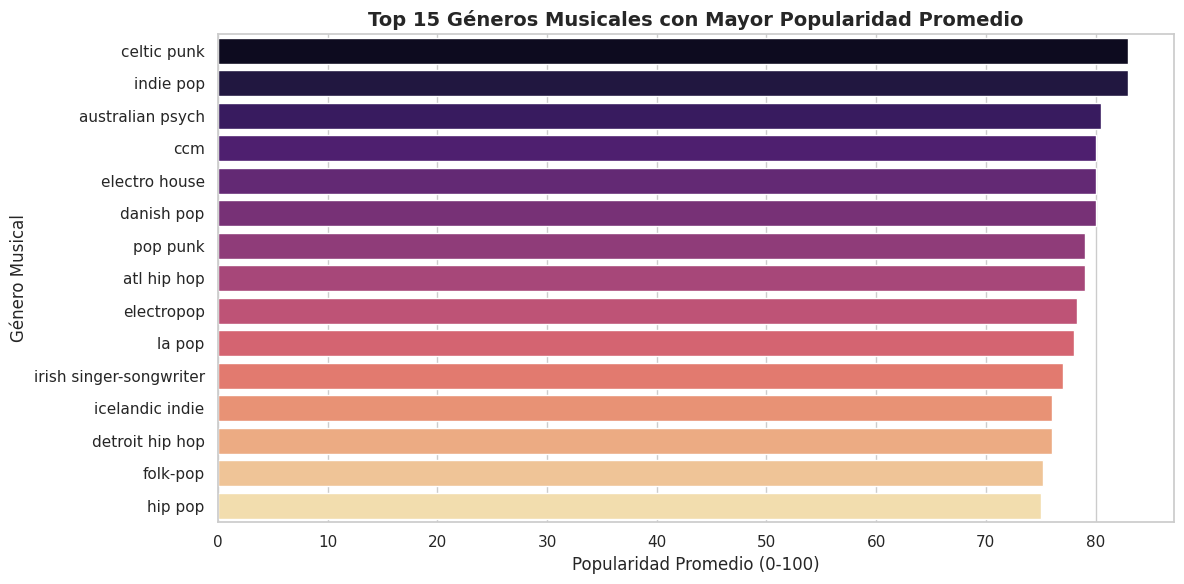

In [ ]:
plt.figure(figsize=(12, 6))

# Calculamos el promedio, tomamos los 15 mejores y lo volvemos un DataFrame
top_genres = df.groupby('top_genre', observed=True)['popularity'].mean().sort_values(ascending=False).head(15).reset_index()

# EL TRUCO: Convertir la categoría a texto para que la gráfica olvide el resto de los géneros
top_genres['top_genre'] = top_genres['top_genre'].astype(str)

# Graficamos usando el DataFrame limpio
sns.barplot(data=top_genres, x='popularity', y='top_genre', palette='magma')

plt.title('Top 15 Géneros Musicales con Mayor Popularidad Promedio', fontweight='bold', fontsize=14)
plt.xlabel('Popularidad Promedio (0-100)', fontsize=12)
plt.ylabel('Género Musical', fontsize=12)

# tight_layout() asegura que los textos largos no se corten en los bordes
plt.tight_layout()
plt.show()


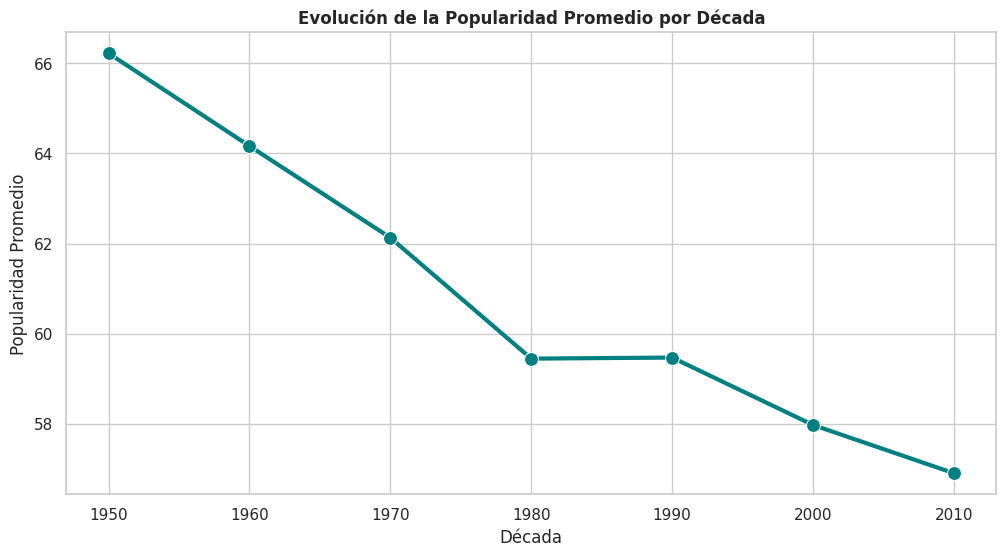

In [ ]:
# =====================================================================
# ¿Qué décadas concentran canciones con mejor desempeño?
# =====================================================================
# Creamos la columna de década matemáticamente
df['decade'] = (df['year'] // 10) * 10

plt.figure()
decades_pop = df.groupby('decade')['popularity'].mean().reset_index()
sns.lineplot(data=decades_pop, x='decade', y='popularity', marker='o', color='teal', linewidth=3, markersize=10)
plt.title('Evolución de la Popularidad Promedio por Década', fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Popularidad Promedio')
plt.xticks(decades_pop['decade']) # Para que muestre años exactos (1980, 1990...)
plt.show()



In [ ]:
df_2.head()


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          4810 non-null   int64 
 1   title         4810 non-null   object
 2   published_at  4810 non-null   object
 3   updated_at    4810 non-null   object
 4   category      4810 non-null   object
 5   nominee       4804 non-null   object
 6   artist        2970 non-null   object
 7   workers       2620 non-null   object
 8   img           3443 non-null   object
 9   winner        4810 non-null   bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 343.0+ KB


In [ ]:

#  Revisión y Eliminación de Duplicados
num_duplicados = df_2.duplicated().sum()
print(f"\n[INFO] Registros duplicados detectados: {num_duplicados}")
if num_duplicados > 0:
    print("Mostrando filas duplicadas:")
    print(df[df.duplicated()])
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print("Duplicados eliminados exitosamente.")


[INFO] Registros duplicados detectados: 0


In [ ]:
df_2['published_at'] = pd.to_datetime(df_2['published_at'], utc=True)
df_2['updated_at'] = pd.to_datetime(df_2['updated_at'], utc=True)

print("Tipos de datos actualizados para df_2:")
print(df_2[['published_at', 'updated_at']].info())

Tipos de datos actualizados para df_2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   published_at  4810 non-null   datetime64[ns, UTC]
 1   updated_at    4810 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2)
memory usage: 75.3 KB
None


In [ ]:
print("Datos nulos en df_2:")
print(df_2.isnull().sum())

Datos nulos en df_2:
year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64


In [ ]:
df_2['artist'] = df_2['artist'].fillna('Unknown')
df_2['workers'] = df_2['workers'].fillna('Unkonwn')
df_2['img'] = df_2['img'].fillna('Unkonwn')
df_2 = df_2.dropna(subset=['nominee'])

print("Datos nulos en df_2:")
print(df_2.isnull().sum())

Datos nulos en df_2:
year            0
title           0
published_at    0
updated_at      0
category        0
nominee         0
artist          0
workers         0
img             0
winner          0
dtype: int64


In [ ]:
# Nota: Pasamos a minúsculas para evitar que 'Gorillaz' y 'gorillaz' no coincidan por una letra
df['title_lower'] = df['title'].str.lower().str.strip()
df['artist_lower'] = df['artist'].str.lower().str.strip()

df_2['nominee_lower'] = df_2['nominee'].str.lower().str.strip()
df_2['artist_lower'] = df_2['artist'].str.lower().str.strip()

# Unimos de forma horizontal
df_features_premios = pd.merge(
    df,
    df_2[['nominee_lower', 'artist_lower', 'category', 'winner']],
    left_on=['title_lower', 'artist_lower'],
    right_on=['nominee_lower', 'artist_lower'],
    how='inner'
)

# Limpieza de columnas temporales de cruce
df_features_premios = df_features_premios.drop(columns=['title_lower', 'nominee_lower', 'artist_lower'])

print(f"¡Cruce exitoso! Encontramos {len(df_features_premios)} canciones que están en el Top 2000 de Spotify y que además fueron nominadas a un premio.")

¡Cruce exitoso! Encontramos 138 canciones que están en el Top 2000 de Spotify y que además fueron nominadas a un premio.
